# Uczenie nadzorowane - Predykcja

**Opracowanie:** Kajetan Kowalski 421071   
**Labolatorium:**  11.12.2025

---

<br><br>


## 1. Pobranie danych Boston Housing Dataset

In [166]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX',
         'PTRATIO','B','LSTAT','MEDV']
dataset = pd.read_csv(url, delim_whitespace=True, names=names)
print(dataset.head(10))

/tmp/ipython-input-2890233009.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = pd.read_csv(url, delim_whitespace=True, names=names)


      CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575   65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421   78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998   45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147   54.2  6.0622    3  222.0   
5  0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222.0   
6  0.08829  12.5   7.87     0  0.524  6.012   66.6  5.5605    5  311.0   
7  0.14455  12.5   7.87     0  0.524  6.172   96.1  5.9505    5  311.0   
8  0.21124  12.5   7.87     0  0.524  5.631  100.0  6.0821    5  311.0   
9  0.17004  12.5   7.87     0  0.524  6.004   85.9  6.5921    5  311.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396

## 2. Podstawowa EDA

Opis zmiennych:
- Crim - Przestępczość na mieszkańca w danej dzielnicy
- ZN - Procentowy udział terenów przeznaczonych pod zabudowę jednorodzinną o powierzchni powyżej 25000 sq.ft.
- INDUS - Procent terenów usługowych i przemysłowych w danej dzielnicy
- CHAS - Zmienna binarna określająca przyleganie do rzeki Charles (1- tak, 0-nie)
- NOX - Stężenie tlenków azotu, wyrażone w częściach na 10 milionów
- RM - Średnia liczba pokoi na jedno mieszkanie
- AGE - Procent mieszkań wybudowanych przed 1940 rokiem
- DIS - Wskaźnik odległości do pięciu głównych centrów zatrudnienia w Bostonie
- RAD - Indeks dostępności do autostrad
- TAX - Stawka podatku od nieruchomości na każde 10 000 USD wartości nieruchomości
- PTRATIO - (ang. Pupil, Teacher) - stosunek liczby uczniów do liczby nauczycieli w szkołach publicznych w dzielnicy
- B - 1000(Bk - 0.63)^2, gdzie Bk jest proporcją osób czarnoskórych przpadających na miasto
- LSTAT - Procent populacji o niskim statusie społeczno-ekonomicznym
- MEDV - Mediana wartości domów, wyrażona w tysiącach dolarów.

In [167]:
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695   

Zbiór danych zawiera 506 obserwacji. Na podstawie statystyk opisowych można wyciągnąć następujące wnioski:

- Średnia cena domu (`MEDV`) wynosi **22,53 tys. USD** (mediana = 21,2 tys. USD), przy dość dużym rozrzucie (od 5 do 50 tys. USD).
- Większość domów w zbiorze została wybudowana przed 1970 rokiem (75% ma `AGE` > 94 lata).
- Tylko **7%** nieruchomości graniczy z rzeką Charles (`CHAS` = 1).
- Występuje duża zmienność poziomu przestępczości (`CRIM` od 0,006 do 88,98) oraz stawek podatku od nieruchomości (`TAX` od 187 do 711).
- Średni współczynnik liczby uczniów na nauczyciela (`PTRATIO`) wynosi 18,46 – im niższy, tym lepsza jakość edukacji w okolicy.
- Zmienna `B` (proporcja mieszkańców afroamerykańskich) przyjmuje w niektórych obserwacjach wartości skrajnie niskie, co może odzwierciedlać historyczne wzorce segregacji rasowej.

In [168]:
missing_values = dataset.isna().sum()
print(missing_values)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


Przeprowadzona analiza brakó danych wskazuje, że rozpatrywany zbiór danych jest kompletny i nie zawiera wartości brakujących.

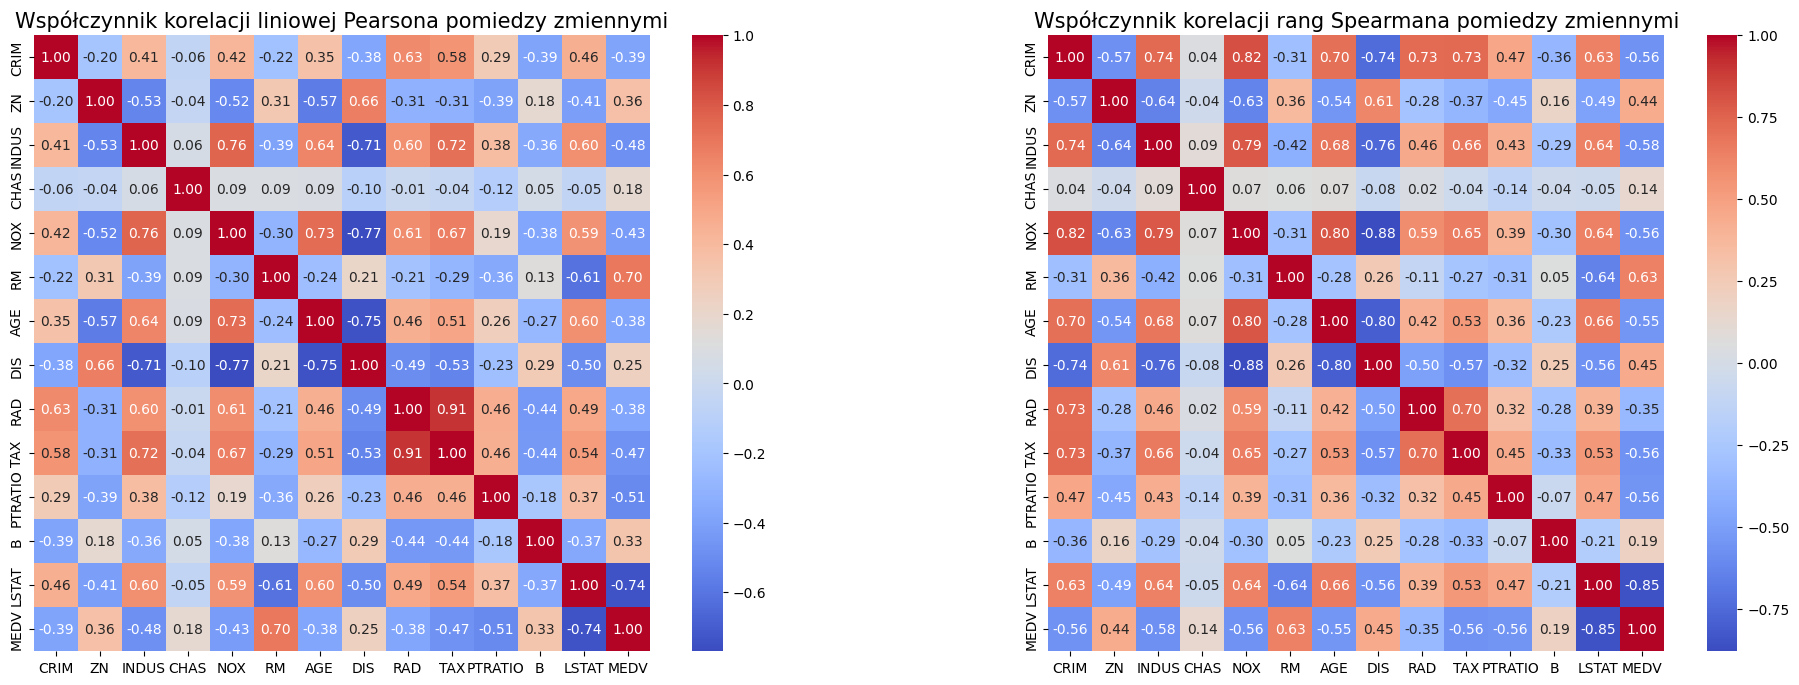

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2,figsize=(24,8))
sns.heatmap(dataset.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", square=True, ax=ax[0])
ax[0].set_title("Współczynnik korelacji liniowej Pearsona pomiedzy zmiennymi",
                fontsize=15)
sns.heatmap(dataset.corr(method="spearman"), annot=True, fmt=".2f",
            cmap="coolwarm", square=True, ax=ax[1])
ax[1].set_title("Współczynnik korelacji rang Spearmana pomiedzy zmiennymi",
                fontsize=15)
plt.show()

1. **Najsilniejsze liniowe powiązania z ceną domu (MEDV)**  
   - Bardzo silna negatywna korelacja z **LSTAT** (Pearson: -0,74; Spearman: -0,85) -> im wyższy odsetek uboższej ludności, tym niższa cena domu.  
   - Silna pozytywna korelacja z **RM** (Pearson: +0,70; Spearman: +0,63) -> im więcej pokoi, tym wyższa cena.

2. **Inne istotne zależności z MEDV**  
   - Negatywna korelacja z: **NOX** (-0,43 Pearson), **INDUS** (-0,48), **TAX** (-0,47), **CRIM** (–0,39), **AGE** (-0,38), **RAD** (-0,38), **PTRATIO** (-0,51).  
   - Wszystkie te zmienne opisują „gorszą” jakość okolicy i obniżają cenę.

3. **Silne korelacje między zmiennymi objaśniającymi (problem multicollinearity)**  
   - **TAX** i **RAD**: +0,91 (Pearson) - wysoki podatek prawie zawsze występuje przy dobrym dostępie do autostrad.  
   - **NOX** silnie skorelowany z **INDUS** (+0,76), **AGE** (+0,73) i **DIS** (-0,77).  
   - **DIS** negatywnie skorelowany z **NOX**, **INDUS** i **AGE** (im dalej od centrum, tym czystsze powietrze i mniej przemysłu).  

4. **Zmienne słabo związane z ceną**  
   - **CHAS** (granica z rzeką) - korelacja bliska zeru.  
   - **B** (wskaźnik rasowy) - słaba korelacja z MEDV (+0,33 Pearson).


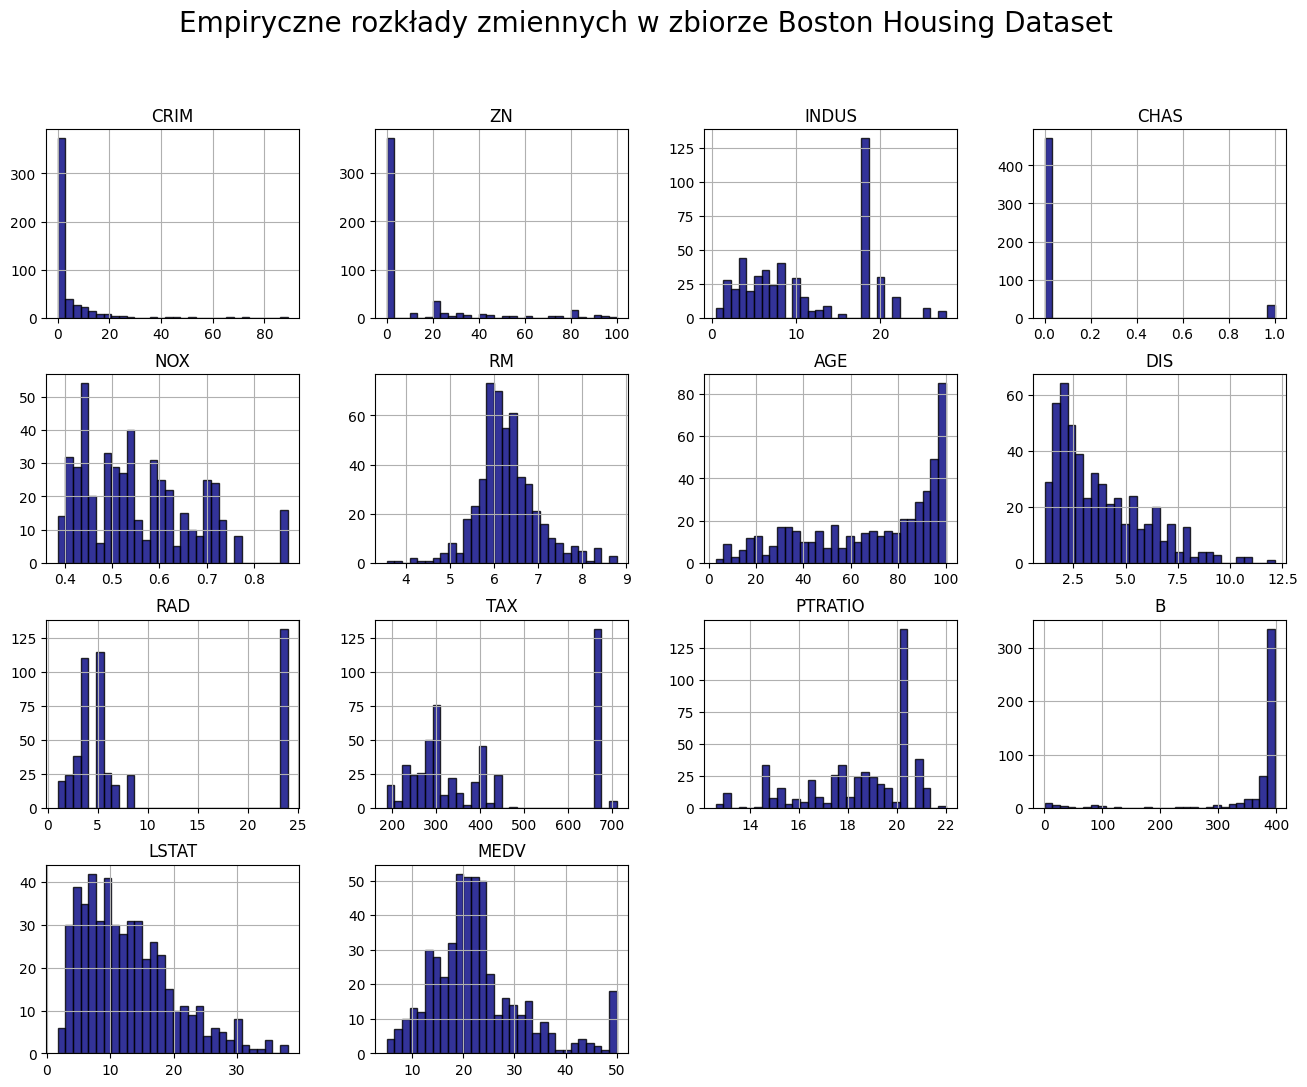

In [170]:
dataset.hist(bins=30, figsize=(16,12), color='navy',
             edgecolor='black', alpha=0.8)
plt.suptitle("Empiryczne rozkłady zmiennych w zbiorze Boston Housing Dataset",
             fontsize=20)
plt.show()

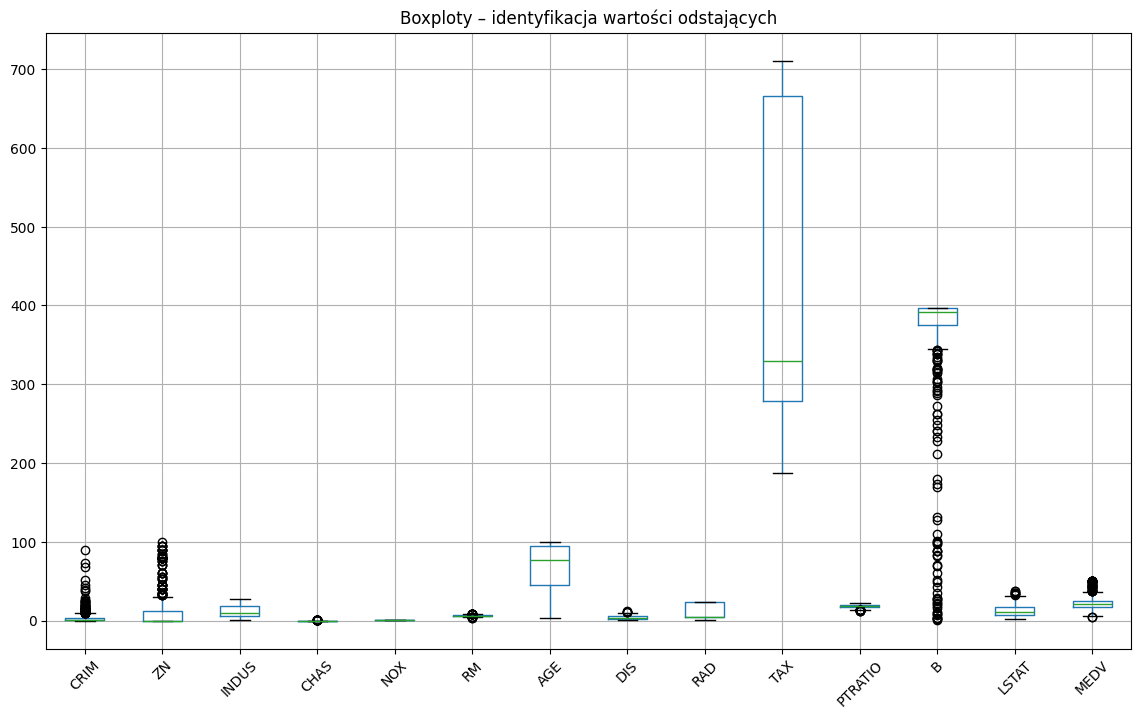

In [171]:
plt.figure(figsize=(14,8))
dataset.boxplot()
plt.title("Boxploty – identyfikacja wartości odstających")
plt.xticks(rotation=45)
plt.show()

Analiza boxplotów ujawnia obecność licznych wartości odstających, szczególnie w zmiennych `CRIM`, `ZN`, `TAX`, `B` oraz `MEDV`. Rozkłady tych zmiennych są silnie prawoskośne, co może negatywnie wpływać na estymację modeli parametrycznych, takich jak regresja liniowa. Jednocześnie modele drzewiaste (np. XGBoost) są znacznie bardziej odporne na obecność obserwacji odstających.

In [172]:
skewness = dataset.drop('MEDV', axis=1).skew().sort_values(ascending=False)
print(skewness)

CRIM       5.223149
CHAS       3.405904
ZN         2.225666
DIS        1.011781
RAD        1.004815
LSTAT      0.906460
NOX        0.729308
TAX        0.669956
RM         0.403612
INDUS      0.295022
AGE       -0.598963
PTRATIO   -0.802325
B         -2.890374
dtype: float64


Analiza skośności rozkładów potwierdza, że wiele zmiennych objaśniających nie spełnia założenia normalności, co w połączeniu z obserwowanymi wartościami odstającymi oraz nieliniowymi relacjami z MEDV tłumaczy ograniczoną skuteczność regresji liniowej oraz przewagę modeli nieliniowych, takich jak XGBoost.

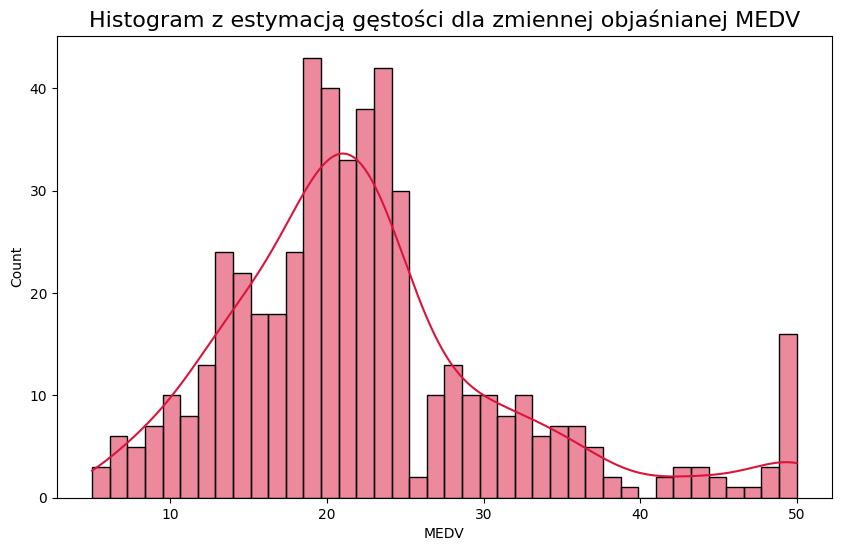

In [173]:
plt.figure(figsize=(10,6))
sns.histplot(dataset['MEDV'], bins=40, kde=True, color='crimson')
plt.title('Histogram z estymacją gęstości dla zmiennej objaśnianej MEDV',
          fontsize=16)
plt.show()

In [174]:
corr = dataset.corr()
S_corr = corr[ (corr.abs() > 0.6) & (corr.abs() < 1) ]
print("Silne korelacje między zmiennymi:")
print(S_corr.dropna(how='all').dropna(axis=1, how='all'))

Silne korelacje między zmiennymi:
           CRIM        ZN     INDUS       NOX        RM       AGE       DIS  \
CRIM        NaN       NaN       NaN       NaN       NaN       NaN       NaN   
ZN          NaN       NaN       NaN       NaN       NaN       NaN  0.664408   
INDUS       NaN       NaN       NaN  0.763651       NaN  0.644779 -0.708027   
NOX         NaN       NaN  0.763651       NaN       NaN  0.731470 -0.769230   
RM          NaN       NaN       NaN       NaN       NaN       NaN       NaN   
AGE         NaN       NaN  0.644779  0.731470       NaN       NaN -0.747881   
DIS         NaN  0.664408 -0.708027 -0.769230       NaN -0.747881       NaN   
RAD    0.625505       NaN       NaN  0.611441       NaN       NaN       NaN   
TAX         NaN       NaN  0.720760  0.668023       NaN       NaN       NaN   
LSTAT       NaN       NaN  0.603800       NaN -0.613808  0.602339       NaN   
MEDV        NaN       NaN       NaN       NaN  0.695360       NaN       NaN   

            RAD  

In [175]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = dataset.drop('MEDV', axis=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(
    len(X_vif.columns))]
print(vif_data)

    Feature        VIF
0      CRIM   2.100373
1        ZN   2.844013
2     INDUS  14.485758
3      CHAS   1.152952
4       NOX  73.894947
5        RM  77.948283
6       AGE  21.386850
7       DIS  14.699652
8       RAD  15.167725
9       TAX  61.227274
10  PTRATIO  85.029547
11        B  20.104943
12    LSTAT  11.102025


## 3. Podział na zbiór treningowy i testowy

In [176]:
from sklearn.model_selection import train_test_split

X = dataset.drop('MEDV', axis=1)
y = dataset['MEDV']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=421071)

## 4. Zastosowanie różnych modeli predykcji

1. **Regresja liniowa (Linear Regression)**  
   Klasyczny model parametryczny zakładający liniową zależność między zmiennymi objaśniającymi a ceną domu.  

   Zalety: bardzo szybki, w pełni interpretowalny, nie wymaga strojenia hiperparametrów.  
   Wady: wrażliwy na multicollinearity, wartości odstające i nieliniowe zależności.

2. **XGBoost (Extreme Gradient Boosting)**  
   Jeden z najpopularniejszych algorytmów gradient boosting opartych na drzewach decyzyjnych.  
   Buduje sekwencyjnie setki/tysiące płytkich drzew, przy czym każde kolejne drzewo koryguje błędy poprzednich.  

3. **XGBoost z optymalizacją hiperparametrów (GridSearchCV)**  
   Ten sam algorytm XGBoost, ale z automatycznym przeszukiwaniem siatki hiperparametrów, m.in.:
   - `learning_rate`  
   - `max_depth`  
   - `n_estimators`   

   Celem było znalezienie kombinacji dającej najlepszą skuteczność na zbiorze walidacyjnym.

<br><br>

### Regresja liniowa

In [177]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

linreg.fit(X_train, y_train)
y_pred_linreg = linreg.predict(X_test)

### XGBoost

In [178]:
import xgboost as xgb

xgb_P= Pipeline([
    ('model', xgb.XGBRegressor(
        objective="reg:squarederror",
        colsample_bytree=0.3,
        learning_rate=0.1,
        max_depth=5,
        alpha=10,
        n_estimators=10,
        random_state=421071
    ))
])

xgb_P.fit(X_train, y_train)
y_pred_xgb = xgb_P.predict(X_test)

## 5. Zastosowanie GridSearchCV

In [179]:
from sklearn.model_selection import GridSearchCV

params = {'model__learning_rate': [0.01, 0.1, 0.3],
          'model__max_depth': [3,5,7],
          'model__n_estimators':[50,100,200]}

xg_reg = Pipeline([
    ('model', xgb.XGBRegressor(
        objective='reg:squarederror',
        colsample_bytree=0.3
    ))
])

grid = GridSearchCV(estimator=xg_reg, param_grid=params,
                    cv=5, scoring='neg_mean_squared_error')

grid.fit(X_train, y_train)
y_pred_grid = grid.predict(X_test)

print("Best score: %f using params: %s" % (grid.best_score_, grid.best_params_))

Best score: -12.005714 using params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


## 6. Porównanie wyników różnych modeli

In [180]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regresja liniowa
print('Linear Regression - MSE: ', mean_squared_error(y_test, y_pred_linreg))
print('Linear Regression - MAE: ', mean_absolute_error(y_test, y_pred_linreg))
print('Linear Regression - R2:  ', r2_score(y_test, y_pred_linreg))

# XGBoost (manualny)
print('XGBoost - MSE: ', mean_squared_error(y_test, y_pred_xgb))
print('XGBoost - MAE: ', mean_absolute_error(y_test, y_pred_xgb))
print('XGBoost - R2:  ', r2_score(y_test, y_pred_xgb))

# XGBoost po GridSearchCV
print('XGBoost (GridSearch) - MSE: ', mean_squared_error(y_test, y_pred_grid))
print('XGBoost (GridSearch) - MAE: ', mean_absolute_error(y_test, y_pred_grid))
print('XGBoost (GridSearch) - R2:  ', r2_score(y_test, y_pred_grid))

Linear Regression - MSE:  28.96956665909741
Linear Regression - MAE:  3.53621190561026
Linear Regression - R2:   0.6947702793482107
XGBoost - MSE:  44.08365403518445
XGBoost - MAE:  4.535370071261537
XGBoost - R2:   0.5355249332925747
XGBoost (GridSearch) - MSE:  13.5529995578699
XGBoost (GridSearch) - MAE:  2.357106749216715
XGBoost (GridSearch) - R2:   0.8572026182606578


#### Omówienie wyników poszczególnych modeli

1. **Regresja liniowa**  
   - MSE = 28.97, MAE = 3 536 USD, R^2 = 0.695  
   - Jak na tak prosty model bez żadnych hiperparametrów - wynik bardzo przyzwoity.  
   - Oznacza to, że model wyjaśnia prawie 70% zmienności cen domów przy założeniu liniowości (jeszcze do zweryfikowania).  
   - Średni błąd bezwzględny ok. 3,5 tys. USD jest akceptowalny, ale widać, że model ma ograniczenia wynikające z multicollinearity i nieliniowych zależności w danych.

2. **XGBoost**  
   - MSE = 44.08, MAE = 4 536 USD, R^2 = 0.536  
   - Najgorszy wynik ze wszystkich trzech modeli - gorszy nawet od regresji liniowej    
   - Pokazuje, jak bardzo wrażliwy jest ten algorytm na dobór hiperparametrów.

3. **XGBoost po optymalizacji hiperparametrów (GridSearchCV)**  
   - MSE = 13.55, MAE = 2 357 USD, R^2 = 0.857  
   - Zdecydowanie najlepszy model w teście.  
   - R^2 = 0.857 oznacza, że model wyjaśnia 85.7% zmienności cen domów na danych, których nigdy nie widział.  
   - Średni błąd przewidywania ceny wynosi tylko ok. 2 360 USD - to bardzo dobry wynik jak na ten zbiór danych.  
   - Poprawa względem regresji liniowej: MSE mniejsze ponad 2-krotnie, R^2 wyższe o prawie 16 punktów procentowych.

#### Wnioski

- Prosta regresja liniowa okazała się zaskakująco konkurencyjna i może być użyta jako solidny model bazowy (jeżeli spełnione są założenia).
- XGBoost całkowicie się nie sprawdził - osiągnął najgorszy wynik, co potwierdza konieczność optymalizacji tego algorytmu.
- XGBoost po zastosowaniu GridSearchCV wyraźnie zwyciężył we wszystkich metrykach i jest zdecydowanie najlepszym modelem w tym zadaniu.
- Ostateczny model XGBoost z dostrojonymi hiperparametrami osiągnął bardzo wysoki poziom predykcji (R^2 = 0.86).

## 7. Sprawdzenie założen dla regresji liniowej

Założenia które muszą być spełnione to:

1. Liniowość - musi istnieć liniowa zależność między predyktorami, a zmienną objaśnianą.
2. Normalność rozkładów reszt - naruszenie może powodować problemy ze zmniejszaniem lub zwiększaniem przedziałów ufności.
3. Homoskedastyczność - równe rozproszenie. Cecha modelu regresji która implikuje, że wariancja błędów jest stała w czasie.

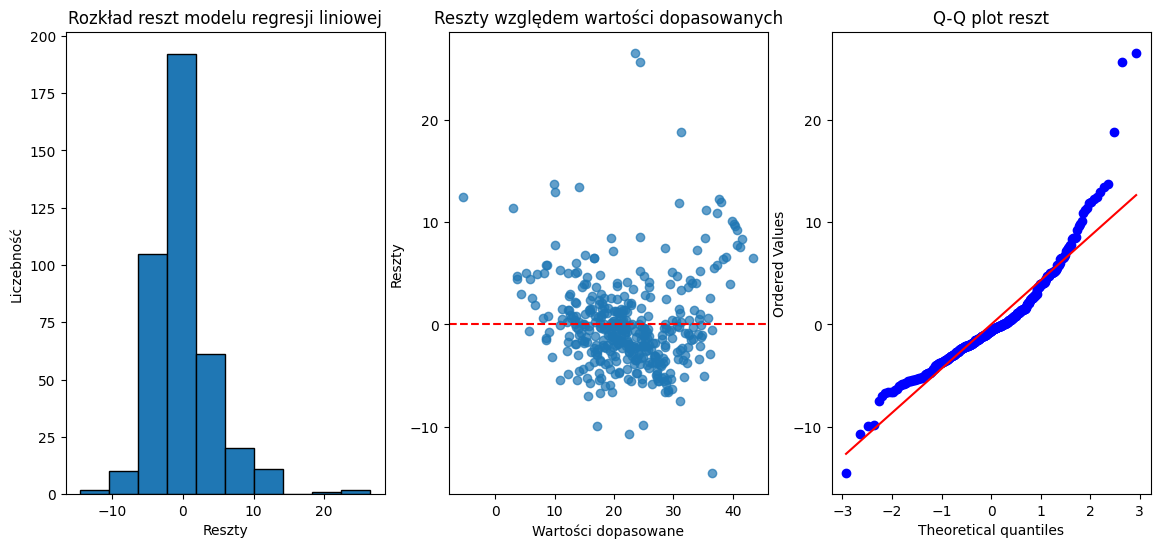

In [182]:
import numpy as np
import scipy.stats as stats
y_pred_train = linreg.predict(X_train)
res_Lin= y_train - y_pred_train

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

ax[0].hist(res_Lin, bins=int(np.ceil(np.log2(len(res_Lin)) + 1)),
           edgecolor='black')
ax[0].set_xlabel("Reszty")
ax[0].set_ylabel("Liczebność")
ax[0].set_title("Rozkład reszt modelu regresji liniowej")

ax[1].scatter(y_pred_train, res_Lin, alpha=0.7)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel("Wartości dopasowane")
ax[1].set_ylabel("Reszty")
ax[1].set_title("Reszty względem wartości dopasowanych")

plt.sca(ax[2])
stats.probplot(res_Lin, dist="norm", plot=plt)
ax[2].set_title("Q-Q plot reszt")


plt.show()

In [185]:
from scipy.stats import shapiro
shapiro(res_Lin)

ShapiroResult(statistic=np.float64(0.8994811373589328), pvalue=np.float64(1.134284420445444e-15))

### Wnioski

1. **Liniowość**:
Założenie nie jest spełnione. Wykres reszt względem wartości dopasowanych ujawnia systematyczny wzorzec w kształcie litery "U", co wskazuje na nieliniową zależność między zmiennymi. Model liniowy nie jest odpowiedni dla tych danych.

2. **Normalność rozkładu reszt**:
Histogram reszt jest silnie prawoskośny (długi ogon dodatni). Q-Q plot pokazuje wyraźne odchylenia od czerwonej linii - ciężkie ogony (punkty powyżej linii dla skrajnych wartości).
Wynik testu Shapiro–Wilka jest zgodny z obserwacjami wizualnymi na histogramie oraz wykresie Q–Q, które wskazują na obecność ciężkich ogonów oraz asymetrii rozkładu reszt.

3. **Homoskedastyczność**:
Założenie jest naruszone. Wariancja reszt zmienia się w zależności od wartości dopasowanych - jest mniejsza dla wartości środkowych (15-25) i większa na krańcach rozkładu, co świadczy o heteroskedastyczności.
